### Import relevant libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from transformer_model import TransformerModel

### Load dataset

In [2]:
image_encoder_type = 'clip'  # 'clip' or 'vit'
image_encoder_type

'clip'

In [3]:
X_train, y_train, X_val, y_val, X_test, y_test = np.load(f'../datasets/video_frame_features_{image_encoder_type}_ews30_supervised_data.npz', allow_pickle=True).values()

In [4]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((40000, 30, 512),
 (40000,),
 (5000, 30, 512),
 (5000,),
 (5000, 30, 512),
 (5000,))

In [5]:
SEED = 124
np.random.seed(SEED)
torch.manual_seed(SEED)

# Create data loaders
batch_size = 64
train_loader = DataLoader(list(zip(X_train, y_train)), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(list(zip(X_val, y_val)), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(list(zip(X_test, y_test)), batch_size=batch_size, shuffle=False)

In [6]:
# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Train model using Transformer architecture based on PyTorch

In [7]:
import copy

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_val_loss = float('inf')
        self.early_stop = False
        self.counter = 0
        self.best_model_state = None
        self.best_optimizer_state = None
        self.best_epoch = None

    def __call__(self, val_loss, model, optimizer, epoch):
        if val_loss > self.best_val_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_val_loss = val_loss
            self.best_model_state = copy.deepcopy(model.state_dict())
            self.best_optimizer_state = copy.deepcopy(optimizer.state_dict())
            self.best_epoch = epoch
            self.counter = 0

    def restore_best_model(self, model, optimizer):
        print('Restoring best model...')
        model.load_state_dict(self.best_model_state)
        optimizer.load_state_dict(self.best_optimizer_state) 

In [84]:
# define hyperparameters
input_dim = X_train.shape[2] # number of features
d_model = 256 # embedding dimension
num_heads = 16
num_layers = 2
dim_feedforward = d_model
output_dim = 2 # binary classification with softmax
tl_dropout = 0.3 # transformer layer dropout
nn_dropout = 0.3 # neural network dropout
lr = 1e-5

In [85]:
# Initialize model
model = TransformerModel(input_dim, d_model, num_heads, num_layers, dim_feedforward, output_dim, tl_dropout, nn_dropout).to(device)
model

TransformerModel(
  (embedding): Linear(in_features=512, out_features=256, bias=True)
  (positional_encoding): PositionalEncoding(
    (pos_embed): Embedding(150, 256)
  )
  (encoder_layers): TransformerEncoderLayer(
    (self_attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
    )
    (linear1): Linear(in_features=256, out_features=256, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
    (linear2): Linear(in_features=256, out_features=256, bias=True)
    (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (dropout1): Dropout(p=0.3, inplace=False)
    (dropout2): Dropout(p=0.3, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_feat

In [86]:
# Define loss function and optimizer
n_patience = 20
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
early_stopping = EarlyStopping(patience=n_patience, min_delta=0.00001)

# Schedule learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=int(n_patience/2), verbose=True)

In [87]:
# train model
num_epochs = 100
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for X_train_batch, y_train_batch in train_loader:
        X_train_batch, y_train_batch = X_train_batch.to(device).float(), y_train_batch.to(device)
        
        # forward pass
        outputs = model(X_train_batch)
        loss = criterion(outputs, y_train_batch)
        
        # backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    val_acc = 0
    with torch.no_grad():
        for X_valid_batch, y_valid_batch in val_loader:
            X_valid_batch, y_valid_batch = X_valid_batch.to(device).float(), y_valid_batch.to(device)
            outputs = model(X_valid_batch)
            v_loss = criterion(outputs, y_valid_batch)
            val_loss += v_loss.item()
            probs = torch.softmax(outputs, dim=1)
            val_acc += ((probs.argmax(dim=1) == y_valid_batch).sum().item()) / y_valid_batch.size(0)
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    val_acc /= len(val_loader)
    
    scheduler.step(val_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}], Train_loss: {train_loss:.6f}, Val_loss: {val_loss:.6f}, Val_acc: {val_acc:.6f}')
    early_stopping(val_loss, model, optimizer, epoch+1)
    if early_stopping.early_stop:
        print(f'Early stopping at epoch {epoch+1}')
        break

# load best model
early_stopping.restore_best_model(model, optimizer)
print(f'Best epoch: {early_stopping.best_epoch} with val_ loss: {early_stopping.best_val_loss:.6f}')

Epoch [1/100], Train_loss: 0.155414, Val_loss: 0.019948, Val_acc: 0.996242
Epoch [2/100], Train_loss: 0.015557, Val_loss: 0.011759, Val_acc: 0.998220
Epoch [3/100], Train_loss: 0.011952, Val_loss: 0.009593, Val_acc: 0.998220
Epoch [4/100], Train_loss: 0.010156, Val_loss: 0.007623, Val_acc: 0.998418
Epoch [5/100], Train_loss: 0.009104, Val_loss: 0.006860, Val_acc: 0.998418
Epoch [6/100], Train_loss: 0.008270, Val_loss: 0.007907, Val_acc: 0.998616
Epoch [7/100], Train_loss: 0.007745, Val_loss: 0.005796, Val_acc: 0.998616
Epoch [8/100], Train_loss: 0.007082, Val_loss: 0.005143, Val_acc: 0.998616
Epoch [9/100], Train_loss: 0.006606, Val_loss: 0.006121, Val_acc: 0.998616
Epoch [10/100], Train_loss: 0.006146, Val_loss: 0.004666, Val_acc: 0.998418
Epoch [11/100], Train_loss: 0.006060, Val_loss: 0.005255, Val_acc: 0.998616
Epoch [12/100], Train_loss: 0.005659, Val_loss: 0.008008, Val_acc: 0.997231
Epoch [13/100], Train_loss: 0.005404, Val_loss: 0.007027, Val_acc: 0.998220
Epoch [14/100], Train

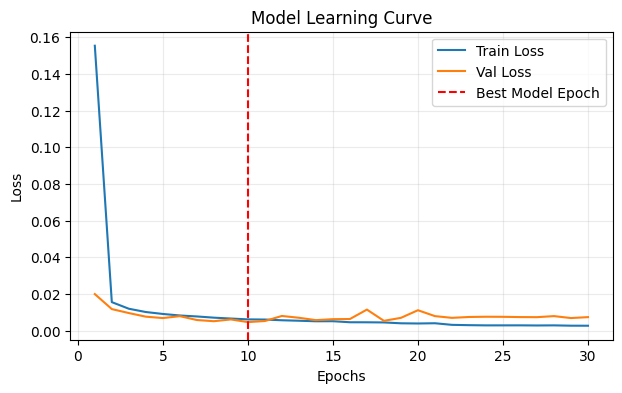

In [88]:
# Plot model learning curve
plt.figure(figsize=(7, 4))
plt.title('Model Learning Curve')
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss')
plt.axvline(x=early_stopping.best_epoch, color='r', linestyle='--', label=f'Best Model Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [89]:
# evaluate model
y_pred = []
y_true = []
y_scores = []

model.eval()
with torch.no_grad():
    for X_test_batch, y_test_batch in test_loader:
        X_test_batch, y_test_batch = X_test_batch.to(device).float(), y_test_batch.to(device)
        y_true.append(y_test_batch.cpu().numpy())
        logits = model(X_test_batch)
        probs = torch.softmax(logits, dim=1)
        y_scores.append(probs[:,1].detach().cpu().numpy()) # get scores for the positive class
        preds = torch.argmax(probs, dim=1).cpu().numpy()
        y_pred.append(preds)

In [90]:
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)
y_scores = np.concatenate(y_scores)

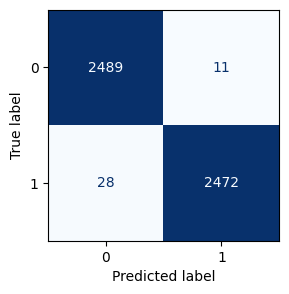

----------------- Classification Report -----------------

              precision    recall  f1-score   support

           0     0.9889    0.9956    0.9922      2500
           1     0.9956    0.9888    0.9922      2500

    accuracy                         0.9922      5000
   macro avg     0.9922    0.9922    0.9922      5000
weighted avg     0.9922    0.9922    0.9922      5000



In [91]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap='Blues', colorbar=None)
fig = disp.figure_
fig.set_figwidth(3)
fig.set_figheight(3) 
plt.grid(False)
plt.show()

# print classification report
print("----------------- Classification Report -----------------\n")
print(classification_report(y_true,y_pred, digits=4))

In [92]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC for the positive class with softmax
# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)
roc_auc

0.99971168

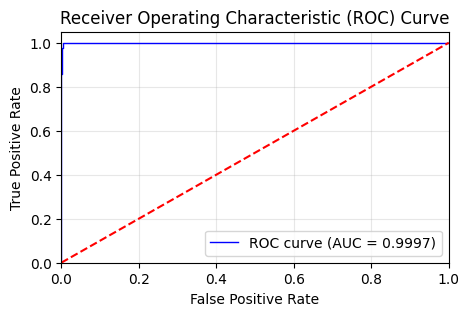

In [93]:
# Plot ROC curve
plt.figure(figsize=(5, 3))
plt.plot(fpr, tpr, color='blue', lw=1, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [94]:
# Define model version
version = 'v5' 

In [95]:
# Saving model

torch.save(model, f'../models/transformer_model_{version}.pt')

# Save training history
with open(f'../models/transformer_train_histories.txt', 'a') as f:
    text = f"version={version}, best_epochs={early_stopping.best_epoch}, auc={roc_auc:.4f}\n"
    text += f"d_model={d_model}, num_heads={num_heads}, num_layers={num_layers}, dim_feedforward={dim_feedforward}\n"
    text += f"tl_dropout={tl_dropout}, nn_dropout={nn_dropout}, lr={lr}\n"
    text += f"image_encoder_type={image_encoder_type}, input_shape={X_train.shape[1:]}\n"
    text += f"{classification_report(y_true,y_pred, digits=4)}\n"
    text += f"{'-'*75}\n"
    f.write(text)